### DECISION TREE

A decision tree learns a set of if–else rules by repeatedly splitting the training data into more “pure” groups, then predicts by following those rules from the root to a leaf.

when your data set is a little complex, you need to devide your data again and again to get a decision boundary, for which decision tree algorithm is used

A Decision Tree is a tree-structured model that:

- Splits data step by step based on feature conditions

- Makes decisions by asking if–else questions

Keep splitting the data until each group becomes as pure as possible.

<img src="decisionGraph.png" width=400/>

“Programmatically speaking, Decision Trees are nothing but a giant structure of nested if–else conditions”

“Mathematically speaking, Decision Trees use hyperplanes which run parallel to any one of the axes to cut your coordinate system into hyper cuboids”

<img src="structure-of-a-decision-tree.png" width=400/>

##### <U>ENTROPY</U>

Entropy is nothing but the measure of disorder. Or you can also call it the measure of purity/impurity

The entropy of a dataset is defined as:

$$
\text{Entropy}(S)
= - \sum_{i=1}^{c} p_i \log_2(p_i)
$$
Where:

- $S$ : Dataset or node
- $c$ : Number of classes
- $p_i$ : Probability of class $i$
- $\log_2$ : Logarithm base 2

if there are two possibilities yes/no and the total number of data points is say, 14
- the number of YES in the target variable  : 9
- the number of NO in the target variable :  4
$$
p_y = \frac{9}{14}
$$
$$
p_n = \frac{5}{14}
$$

##### <u>INFORMATION GAIN</U>

Information Gain tells how much entropy decreases after splitting the data on a feature.

Measures reduction in entropy

Works as a gain (higher is better)

The Information Gain of an attribute $A$ is defined as:

$$
\text{IG}(S, A)
= \text{Entropy}(S)
- \sum_{v \in \text{Values}(A)}
\frac{|S_v|}{|S|}
\; \text{Entropy}(S_v)
$$

Benefits:

- Builds meaningful trees
- Reduces overfitting
- Improves interpretability

Limitation

Biased toward features with many categories

➡️ That’s why Gini Impurity is often preferred

##### <u>GINI IMPURITY</U>

Gini Impurity is an alternative split criterion to Information Gain

Measures how impure a node is

Works as a cost (lower is better)

The Gini Impurity of a dataset is defined as:

$$
\text{Gini}(S)
= 1 - \sum_{i=1}^{c} p_i^2
$$

i can be yes, no and other attributes



> PROGRAM

In [27]:
import pandas as pd
import numpy as np

np.random.seed(42)

companies = ["google", "facebook", "abc pharma", "amazon", "microsoft"]
jobs = ["sales executive", "business manager", "computer programmer", "data analyst"]
degrees = ["bachelors", "masters"]

def salary_rule(company, job, degree):
    if company in ["google", "facebook", "amazon"]:
        if job in ["business manager", "computer programmer"]:
            return 1
        if job == "data analyst" and degree == "masters":
            return 1
    if company == "microsoft" and degree == "masters":
        return 1
    return 0

data = []

for _ in range(150):
    company = np.random.choice(companies)
    job = np.random.choice(jobs)
    degree = np.random.choice(degrees)
    salary = salary_rule(company, job, degree)

    data.append([company, job, degree, salary])

df = pd.DataFrame(
    data,
    columns=["company", "job", "degree", "salary_more_than_100k"]
)

df



,company,job,degree,salary_more_than_100k
0,amazon,sales executive,bachelors,0
1,abc pharma,data analyst,bachelors,0
2,microsoft,computer programmer,masters,1
3,abc pharma,computer programmer,bachelors,0
4,abc pharma,data analyst,bachelors,0
...,...,...,...,...
145,google,computer programmer,masters,1
146,microsoft,business manager,bachelors,0
147,facebook,computer programmer,masters,1
148,google,data analyst,bachelors,0


In [28]:
inputs=df.drop("salary_more_than_100k",axis='columns')
target=df['salary_more_than_100k']
inputs.head

<bound method NDFrame.head of         company                  job     degree
0        amazon      sales executive  bachelors
1    abc pharma         data analyst  bachelors
2     microsoft  computer programmer    masters
3    abc pharma  computer programmer  bachelors
4    abc pharma         data analyst  bachelors
..          ...                  ...        ...
145      google  computer programmer    masters
146   microsoft     business manager  bachelors
147    facebook  computer programmer    masters
148      google         data analyst  bachelors
149      amazon     business manager  bachelors

[150 rows x 3 columns]>

In [29]:
# SINCE THE ML MODELS CAN ONLY UNDERSTAND NUMBERS WE NEED TO CHANGE IT INTO NUMBERS
from sklearn.preprocessing import LabelEncoder

In [30]:
encoder_cmpny=LabelEncoder()
encoder_job=LabelEncoder()
encoder_degree=LabelEncoder()

'''
WHY DIFFERENT ENCODER FOR EACH FEATURE?

✔ Each encoder remembers its own mapping
✔ No conflict
✔ Safe inverse transformation
✔ Correct predictions later

'''

'\nWHY DIFFERENT ENCODER FOR EACH FEATURE?\n\n✔ Each encoder remembers its own mapping\n✔ No conflict\n✔ Safe inverse transformation\n✔ Correct predictions later\n\n'

In [31]:
inputs['company_n']=encoder_cmpny.fit_transform(inputs['company'])
inputs['job_n']=encoder_job.fit_transform(inputs['job'])
inputs['degree_n']=encoder_degree.fit_transform(inputs['degree'])
inputs

,company,job,degree,company_n,job_n,degree_n
0,amazon,sales executive,bachelors,1,3,0
1,abc pharma,data analyst,bachelors,0,2,0
2,microsoft,computer programmer,masters,4,1,1
3,abc pharma,computer programmer,bachelors,0,1,0
4,abc pharma,data analyst,bachelors,0,2,0
...,...,...,...,...,...,...
145,google,computer programmer,masters,3,1,1
146,microsoft,business manager,bachelors,4,0,0
147,facebook,computer programmer,masters,2,1,1
148,google,data analyst,bachelors,3,2,0


In [32]:
inputs_n=inputs.drop(['company','job','degree'],axis='columns')
inputs_n

,company_n,job_n,degree_n
0,1,3,0
1,0,2,0
2,4,1,1
3,0,1,0
4,0,2,0
...,...,...,...
145,3,1,1
146,4,0,0
147,2,1,1
148,3,2,0


In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(inputs_n,target)

In [34]:
from sklearn import tree

In [35]:
model=tree.DecisionTreeClassifier()

In [36]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
model.score(inputs_n,target)

1.0

In [38]:
model.predict([[2,2,1]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [39]:
model.predict([[0,4,2]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [40]:
from sklearn.metrics import confusion_matrix,classification_report

In [41]:
y_pred=model.predict(X_test)

In [42]:
import seaborn as sns

<Axes: >

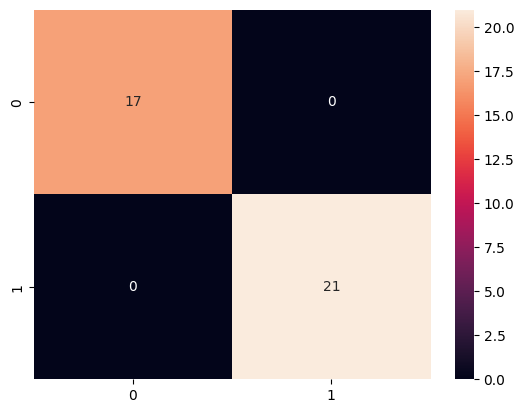

In [43]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        21

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [45]:
import seaborn as sns

In [46]:
df=sns.load_dataset('Iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [47]:
target=df['species']
input=df.drop('species',axis='columns')


In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
encoder=LabelEncoder()

In [50]:
target_n= encoder.fit_transform(target)
target_n

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
model= DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    ccp_alpha=0.0
)

In [53]:
model.fit(input,target_n)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
model.score(input,target_n)
input

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [55]:
model.predict([[4.1,3.2,1.3,0.1]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [56]:
model.predict([[1.7,4.5,1.0,0.1]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [57]:
model.predict([[4.3,5.2,1.6,2.2]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])